## Goal (at MVP Stage):
- Build a working prototype model to estimate menopause status or age.
- Use reliable, well-populated features that still hold clinical relevance.
- Ensure the model trains effectively and generalizes on current data.

*What “Menopause” Means (Clinically):*
Menopause is officially diagnosed after 12 consecutive months without a menstrual period (not caused by pregnancy, illness, or medication).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
import statsmodels.formula.api as smf
import os
import re                                                                                                           
from Load_process_data_v1 import get_process_Data
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
#warnings.filterwarnings(action='once')

## Either preprocess Data...

In [2]:
summary_df, filtered_summary_df, df_classification = get_process_Data(data_dir = "Data", filename = "RHQ_J.xpt")
df_classification['Menopausal_Status'] = (df_classification['RHQ031'] == 2).astype(int)
display(df_classification.head())

# Uncomment to Save the DataFrame to a CSV file
# df_classification.to_csv('df_classification.csv', index=False)

Reproductive_Health_df shape: (3286, 48)
Final merged_df shape: (1901, 79)
Retained 40 columns out of 79
df_classification.shape: (1901, 40)


,SEQN,RHQ010,RHQ031,RHD043,RHQ060,RHQ074,RHQ076,RHQ078,RHQ131,RHQ160,...,MCQ160M,MCQ220,PUQ100,PUQ110,SMQ020,WHD010,WHD020,WHD120,WHD130,Menopausal_Status
0,93705.0,12.0,2.0,0.0,50.0,0.0,0.0,0.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,63.0,165.0,130.0,63.0,1
1,93708.0,14.0,2.0,0.0,48.0,0.0,0.0,0.0,1.0,3.0,...,2.0,2.0,2.0,2.0,2.0,60.0,118.0,100.0,60.0,1
2,93714.0,10.0,2.0,0.0,52.0,2.0,2.0,2.0,1.0,1.0,...,0.0,2.0,1.0,2.0,1.0,60.0,210.0,130.0,60.0,1
3,93721.0,9.0,2.0,0.0,50.0,0.0,0.0,0.0,1.0,5.0,...,2.0,2.0,2.0,2.0,2.0,61.0,180.0,125.0,61.0,1
4,93726.0,13.0,2.0,0.0,55.0,0.0,0.0,0.0,1.0,7.0,...,2.0,2.0,2.0,2.0,1.0,61.0,162.0,118.0,61.0,1


## Or Load the preprocessed Data

In [3]:
# Read the CSV file into a DataFrame
df_classification = pd.read_csv('df_classification.csv')
display(df_classification.head())

,SEQN,RHQ010,RHQ031,RHD043,RHQ060,RHQ074,RHQ076,RHQ078,RHQ131,RHQ160,...,MCQ160M,MCQ220,PUQ100,PUQ110,SMQ020,WHD010,WHD020,WHD120,WHD130,Menopausal_Status
0,93705.0,12.0,2.0,0.0,50.0,0.0,0.0,0.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,63.0,165.0,130.0,63.0,1
1,93708.0,14.0,2.0,0.0,48.0,0.0,0.0,0.0,1.0,3.0,...,2.0,2.0,2.0,2.0,2.0,60.0,118.0,100.0,60.0,1
2,93714.0,10.0,2.0,0.0,52.0,2.0,2.0,2.0,1.0,1.0,...,0.0,2.0,1.0,2.0,1.0,60.0,210.0,130.0,60.0,1
3,93721.0,9.0,2.0,0.0,50.0,0.0,0.0,0.0,1.0,5.0,...,2.0,2.0,2.0,2.0,2.0,61.0,180.0,125.0,61.0,1
4,93726.0,13.0,2.0,0.0,55.0,0.0,0.0,0.0,1.0,7.0,...,2.0,2.0,2.0,2.0,1.0,61.0,162.0,118.0,61.0,1


## Growth curve approach steps:

- Create Menopausal_Status from RHQ031

- Fit logistic regression on Age (and covariates)

- Plot predicted probability curves

- Stratify by risk factors


## 🎯 Our immediate goal:
- Modeling the probability of menopause (Menopausal_Status, binary) as a function of age.


In [4]:
# Fit logistic regression
df_growth = df_classification[['RIDAGEYR', 'Menopausal_Status']].dropna()
logit_model = smf.logit(
    formula='Menopausal_Status ~ RIDAGEYR',
    data=df_growth
).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.251216
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      Menopausal_Status   No. Observations:                 1901
Model:                          Logit   Df Residuals:                     1899
Method:                           MLE   Df Model:                            1
Date:                Sun, 26 Jul 2026   Pseudo R-squ.:                  0.6345
Time:                        19:43:01   Log-Likelihood:                -477.56
converged:                       True   LL-Null:                       -1306.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.1183      0.522    -21.317      0.000     -12.141     -10.096
RIDAGEYR       0.2268      0.

### Visualize the Predicted Curve
- Now let's plot the S-shaped curve:

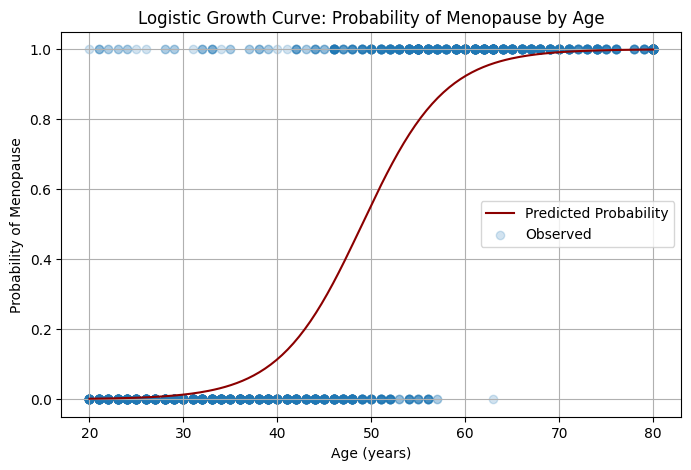

In [5]:

# Create age range
age_range = np.linspace(df_growth['RIDAGEYR'].min(),
                         df_growth['RIDAGEYR'].max(), 200)

# Predict probabilities
age_df = pd.DataFrame({'RIDAGEYR': age_range})
age_df['Predicted_Prob'] = logit_model.predict(age_df)

# Plot
plt.figure(figsize=(8,5))
plt.plot(age_range, age_df['Predicted_Prob'], color='darkred', label='Predicted Probability')
plt.scatter(df_growth['RIDAGEYR'], df_growth['Menopausal_Status'], alpha=0.2, label='Observed')
plt.xlabel('Age (years)')
plt.ylabel('Probability of Menopause')
plt.title('Logistic Growth Curve: Probability of Menopause by Age')
plt.legend()
plt.grid()
plt.show()


### To better visualize your fit:
- Bin the ages (e.g. in 1‑year or 2‑year bins).

- Compute the observed proportion menopausal in each bin.

- Plot those points against your smooth logistic curve.

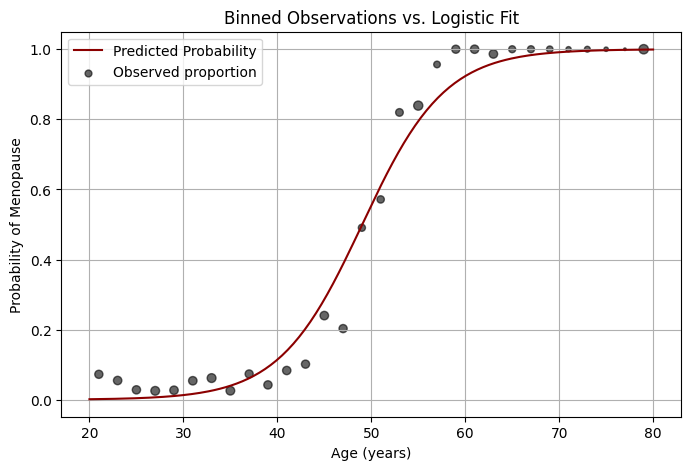

In [ ]:
# 1) Bin ages
df_growth['age_bin'] = pd.cut(df_growth['RIDAGEYR'], bins=np.arange(20, 81, 2))

# 2) Compute observed mean menopausal status in each bin
obs = (
    df_growth
    .groupby('age_bin')['Menopausal_Status']
    .agg(['mean','count'])
    .reset_index()
    .dropna()
)

# 3) Plot
plt.figure(figsize=(8,5))
# logistic fit line
plt.plot(age_range, age_df['Predicted_Prob'], color='darkred', label='Predicted Probability')

# observed points sized by count
plt.scatter(
    obs['age_bin'].apply(lambda x: x.mid), 
    obs['mean'], 
    s=obs['count']*0.5, 
    color='black',
    alpha=0.6,
    label='Observed proportion'
)

plt.xlabel('Age (years)')
plt.ylabel('Probability of Menopause')
plt.title('Binned Observations vs. Logistic Fit')
plt.legend()
plt.grid(True)
plt.show()

## Add Covariates for Richer Growth Curves
- To see how factors modify the curve, add them:

✅ Adding smoking and BMI to the model

In [7]:

# Suppose you have:
# - SMQ020: smoked at least 100 cigarettes in life (1=yes, 2=no)
# - WHD020: current weight (proxy for BMI)

df_growth = df_classification[['RIDAGEYR', 'SMQ020', 'WHD020', 'Menopausal_Status']].dropna()

# Adjust for smoking and weight
logit_model2 = smf.logit(
    formula='Menopausal_Status ~ RIDAGEYR + SMQ020 + WHD020',
    data=df_growth
).fit()

print(logit_model2.summary())

Optimization terminated successfully.
         Current function value: 0.250032
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      Menopausal_Status   No. Observations:                 1901
Model:                          Logit   Df Residuals:                     1897
Method:                           MLE   Df Model:                            3
Date:                Sun, 26 Jul 2026   Pseudo R-squ.:                  0.6362
Time:                        19:43:08   Log-Likelihood:                -475.31
converged:                       True   LL-Null:                       -1306.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.2181      0.666    -15.351      0.000     -11.523      -8.913
RIDAGEYR       0.2273      0.

## Interpretation of the results
✅ Age:

Very strong, highly significant predictor.

Makes sense biologically—probability of menopause increases strongly with age.

✅ Smoking Status (SMQ020):

Negative coefficient (but not significant). This is a bit counterintuitive compared to the unadjusted model!

The non-significance (p = 0.23) suggests no clear evidence smoking status independently predicts menopause status when age and weight are included.

This happens because age already explains most of the variation, and smoking might be somewhat confounded with age.

✅ Weight:

Slight negative association.

Borderline significant (p ≈ 0.058). Heavier women may have slightly lower odds of being menopausal at the same age, but this is weak evidence.

### Stratify predictions:

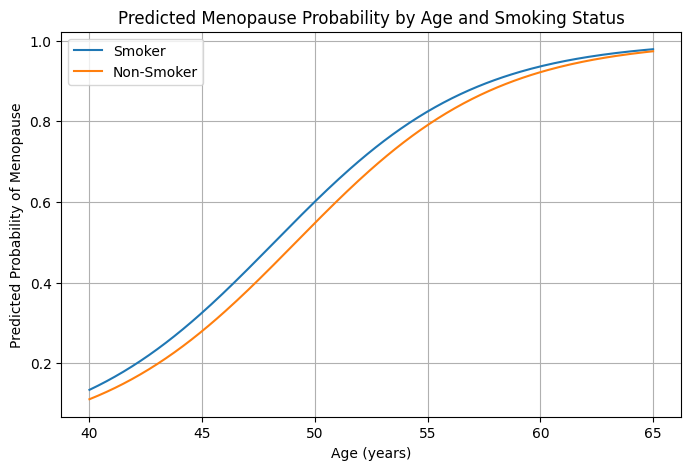

In [8]:
df_growth = df_classification[['RIDAGEYR', 'SMQ020', 'WHD020', 'Menopausal_Status']].dropna()

# Define labels
smoking_labels = {1: 'Smoker', 2: 'Non-Smoker'}

# Plot
plt.figure(figsize=(8,5))
age_grid = np.linspace(40, 65, 200)
for smq in [1, 2]:
    df_pred = pd.DataFrame({
        'RIDAGEYR': age_grid,
        'SMQ020': smq,
        'WHD020': df_growth['WHD020'].median()  # fix weight to median
    })
    plt.plot(
        age_grid,
        logit_model2.predict(df_pred),
        label=smoking_labels[smq]
    )

plt.xlabel('Age (years)')
plt.ylabel('Predicted Probability of Menopause')
plt.title('Predicted Menopause Probability by Age and Smoking Status')
plt.legend()
plt.grid(True)
plt.show()



### Interpretation :
Smokers have higher predicted probability of being menopausal at a given age than non-smokers.

In simpler terms:

⭐ Interpretation:

Smoking is associated with earlier menopause.

This is biologically plausible and actually well-supported in epidemiological literature:

Smoking is a known risk factor for earlier menopause.

Toxins in cigarette smoke can damage ovarian follicles, accelerating ovarian aging.

Population studies often show smokers experiencing menopause ~1–2 years earlier on average.

## Probabilistic classification
- ✅ Now we want individual-level prediction.
- ✅ Goal: Given all features (age, smoking, weight, other health factors), predict each woman’s risk of being menopausal.
- ✅ This lets us identify higher-risk individuals or do personalized risk assessment.

Example of workflow for OPTION 2:
- 1️⃣ Choose target: Menopausal_Status (0/1)
- 2️⃣ Choose features: All relevant predictors you have (exclude SEQN, target itself)
- 3️⃣ Split into train/test
- 4️⃣ Scale / preprocess (handle categorical vars)
- 5️⃣ Fit classification model
- 6️⃣ Evaluate performance
- 7️⃣ Get predicted probabilities

# Machine Learning starts here


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split


In [10]:
# Step 1: Define X and y

## Arrtibutes (Predictors)
# RIDAGEYR - Age at survey
# RHQ010 - Age when first menstrual period occurred
# RHQ420 - Ever taken birth control pills?
# WHD120 - Self-reported weight-age 25 (pounds)
# WHD130 - Self-reported height - age 25 (inches)
# MCQ160m - Ever told you had thyroid problem (too much NaN)
# MCD180m - Age when told you had thyroid problem (too much NaN)
# SMQ621 - Cigarettes smoked in entire life (too much NaN)
# SMQ020 - Smoked at least 100 cigarettes in life

X = df_classification[['RIDAGEYR', 'RHQ010', 'RHQ420', 'WHD120', 'WHD130', 'SMQ020']]
y = df_classification['Menopausal_Status']

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Preprocessing
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


X.head()

,RIDAGEYR,RHQ010,RHQ420,WHD120,WHD130,SMQ020
0,66.0,12.0,1.0,130.0,63.0,1.0
1,66.0,14.0,1.0,100.0,60.0,2.0
2,54.0,10.0,1.0,130.0,60.0,1.0
3,60.0,9.0,1.0,125.0,61.0,2.0
4,67.0,13.0,2.0,118.0,61.0,1.0


#### Step 4: Build Pipelines for Multiple Classifiers

In [11]:
# Define Preprocessing
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Define Classifiers and Param Grids
models_and_parameters = {
    'Logistic Regression': (
        LogisticRegression(max_iter=5000),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(),
        {'clf__n_estimators': [50, 100],
         'clf__max_depth': [None, 5, 10]}
    ),
    'SVM': (
        SVC(probability=True),
        {'clf__C': [0.1, 1, 10],
         'clf__kernel': ['linear', 'rbf']}
    ),
    'Gradient Boosting': (
        HistGradientBoostingClassifier(),
        {'clf__max_iter': [100, 200]}
    ),
    'MLP': (
        MLPClassifier(max_iter=1000),
        {'clf__hidden_layer_sizes': [(50,), (100,)],
         'clf__alpha': [0.0001, 0.001]}
    )
}


# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### Train Models with GridSearchCV

In [12]:
# Step 1: Store Best Models
best_models = {}
results = []

for name, (model, param_grid) in models_and_parameters.items():
    print(f"\nTraining {name}...")
    
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('clf', model)
    ])
    
    grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_models[name] = best_model  # 🔥 save it here
    
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1] if hasattr(best_model, 'predict_proba') else None

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_macro = report['macro avg']['f1-score']
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    #print(f"Best Params: {grid.best_params_}")
    #print(f"Accuracy: {acc:.3f}")
    #print(f"F1 (macro): {f1_macro:.3f}")
    #print(f"ROC AUC: {roc_auc:.3f}")

    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Score (macro)': f1_macro,
        'ROC AUC': roc_auc
    })


# Compare Results in DataFrame
results_df = pd.DataFrame(results).sort_values(by='F1 Score (macro)', ascending=False)
display(results_df)



Training Logistic Regression...



Training Random Forest...

Training SVM...

Training Gradient Boosting...

Training MLP...


,Model,Accuracy,F1 Score (macro),ROC AUC
4,MLP,0.931759,0.930306,0.956356
0,Logistic Regression,0.929134,0.927789,0.960287
1,Random Forest,0.929134,0.927681,0.945470
2,SVM,0.921260,0.919457,0.954907
3,Gradient Boosting,0.910761,0.909000,0.951324


⭐️ 1️⃣ Understand What Your Classifier Outputs
The trained models can predict:

- ✅ Class (0 = not menopausal, 1 = menopausal)
- ✅ Probability (model.predict_proba)

- The probability output is exactly what clinicians want:

“Given age 52, BMI 27, smoker = yes… what is this patient’s predicted risk of menopause?”

### Given her features and her age, what's the probability she's menopausal?

In [13]:

# Step 2: Predict Risk for a New Patient

## Arrtibutes (Predictors)
# RIDAGEYR - Age at survey
# RHQ010 - Age when first menstrual period occurred
# RHQ420 - Ever taken birth control pills?
# WHD120 - Self-reported weight-age 25 (pounds)
# WHD130 - Self-reported height - age 25 (inches)
# SMQ020 - Smoked at least 100 cigarettes in life


def predict_menopause_risk(model, age, menstrual_age, birth_control_pill, 
                           weight, height, smoker,):
    X_new = pd.DataFrame({
        'RIDAGEYR': [age],
        'RHQ010' : [menstrual_age],
        'RHQ420' : [birth_control_pill],
        'WHD120': [weight],
        'WHD130': [height],
        'SMQ020': [smoker],
    })
    proba = model.predict_proba(X_new)[0][1]
    return proba

patient_age = 52 
patient_menstrual_age = 13
patient_taken_birth_control_pill = 1 # 1= yes, 2 = no
patient_weight = 160
patient_height = 65
patient_smokes = 1 # 1= yes, 2 = no

if patient_taken_birth_control_pill == 1:
    bcp_str = 'has taken birth control pill'
elif patient_taken_birth_control_pill == 2:
    bcp_str = 'has never taken birth control pill'
else: 
    bcp_str = 'birth control pill info not available'

if patient_smokes == 1:
    Sm_str = 'is a smoker'
elif patient_smokes == 2:
    Sm_str = 'is not a smoker'
else: 
    Sm_str = 'unavailabe smoking history'
 
risk = predict_menopause_risk(best_models['MLP'], age=patient_age, 
                              menstrual_age=patient_menstrual_age, 
                              birth_control_pill=patient_taken_birth_control_pill, 
                              weight=patient_weight, height=patient_height,
                              smoker=patient_smokes)

print(f"""The patient at age {patient_age}, height and weight at aged 25 {patient_height}in., {patient_weight}lb,
        had thier frist menstrual period at aged {patient_menstrual_age},
        {bcp_str} and {Sm_str}
has a {risk:.2%} Predicted risk of menopause""") 

The patient at age 52, height and weight at aged 25 65in., 160lb,
        had thier frist menstrual period at aged 13,
        has taken birth control pill and is a smoker
has a 71.35% Predicted risk of menopause


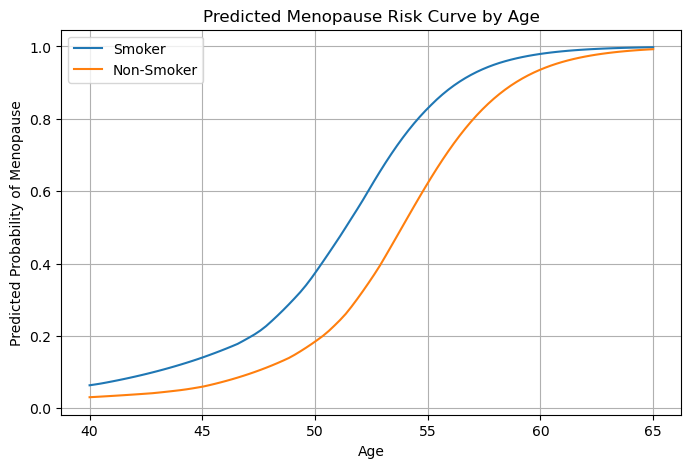

In [14]:
# Step 3: Plot Risk Curve by Age
ages = np.linspace(40, 65, 100)

plt.figure(figsize=(8,5))

for smoker in [1, 2]:
    risks = []
    for age in ages:
        p = predict_menopause_risk(best_models['MLP'], age, 
                                   menstrual_age=13, birth_control_pill= 1,
                                   height=65, weight=200, smoker=smoker)
        risks.append(p)
    label = 'Smoker' if smoker == 1 else 'Non-Smoker'
    plt.plot(ages, risks, label=label)

plt.xlabel('Age')
plt.ylabel('Predicted Probability of Menopause')
plt.title('Predicted Menopause Risk Curve by Age')
plt.legend()
plt.grid()
plt.show()

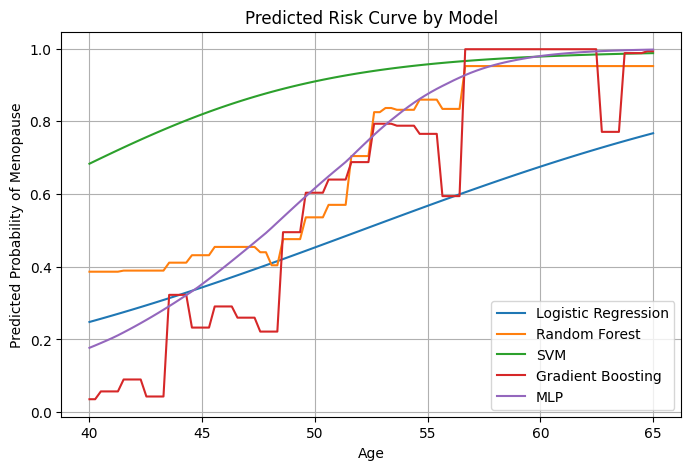

In [14]:
# Step 4: Compare Different Models on the Same Plot
age_grid = np.linspace(40, 65, 100)
smoker = 1
height = 68
weight = 160
menstrual_age = 13
bcp = 1

plt.figure(figsize=(8,5))

for model_name, model in best_models.items():
    risks = [predict_menopause_risk(model, age, 
                menstrual_age=menstrual_age, birth_control_pill= bcp,
                height=height, weight=weight, smoker=smoker) for age in age_grid]
    plt.plot(age_grid, risks, label=model_name)

plt.xlabel('Age')
plt.ylabel('Predicted Probability of Menopause')
plt.title('Predicted Risk Curve by Model')
plt.legend()
plt.grid()
plt.show()


### Menopause Age Predition
1️⃣ Generate the risk curve across ages. Predict for ages 40–65 for this patient’s other features.

2️⃣ Find the age at which the predicted risk crosses 50% (or other threshold).


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def estimate_menopause_age_curve(
    model,
    patient_features,
    age_range=(40, 65),
    thresholds=[0.5],
    plot=True
):
    """
    Estimate age of menopause risk crossing given thresholds, and optionally plot the curve.

    Parameters
    ----------
    model : trained sklearn model
        Must implement predict_proba.

    patient_features : dict
        Must include:
            - RHQ010 : Age at first period
            - RHQ420 : Ever taken birth control pills (1=yes, 2=no)
            - WHD120 : Weight at age 25
            - WHD130 : Height at age 25
            - SMQ020 : Smoked 100 cigarettes (1=yes, 2=no)

    age_range : tuple
        (min_age, max_age) range to evaluate, default (40, 65)

    thresholds : list
        List of probability thresholds to check, default [0.5]

    plot : bool
        Whether to plot the risk curve

    Returns
    -------
    dict
        Keys are thresholds, values are estimated ages
    """

    # 1) Build age grid
    ages = np.linspace(age_range[0], age_range[1], 200)
    probs = []

    # 2) Predict probabilities across age
    for age in ages:
        X_new = pd.DataFrame({
            'RIDAGEYR': [age],
            'RHQ010': [patient_features['RHQ010']],
            'RHQ420': [patient_features['RHQ420']],
            'WHD120': [patient_features['WHD120']],
            'WHD130': [patient_features['WHD130']],
            'SMQ020': [patient_features['SMQ020']],
        })
        proba = model.predict_proba(X_new)[0][1]
        probs.append(proba)

    # 3) Find crossing ages for thresholds
    estimated_ages = {}
    for threshold in thresholds:
        est_age = None
        for a, p in zip(ages, probs):
            if p >= threshold:
                est_age = a
                break
        estimated_ages[threshold] = est_age

    # 4) Optional plot
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(ages, probs, label='Predicted Risk Curve')
        for threshold in thresholds:
            plt.axhline(threshold, color='red', linestyle='--', label=f'{int(threshold*100)}% Threshold')
            if estimated_ages[threshold]:
                plt.axvline(estimated_ages[threshold], color='grey', linestyle=':',
                            label=f'~{estimated_ages[threshold]:.1f} years (at {int(threshold*100)}%)')
        plt.xlabel('Age')
        plt.ylabel('Predicted Probability of Menopause')
        plt.title('Estimated Menopause Risk Curve')
        plt.legend()
        plt.grid()
        plt.show()

    return estimated_ages


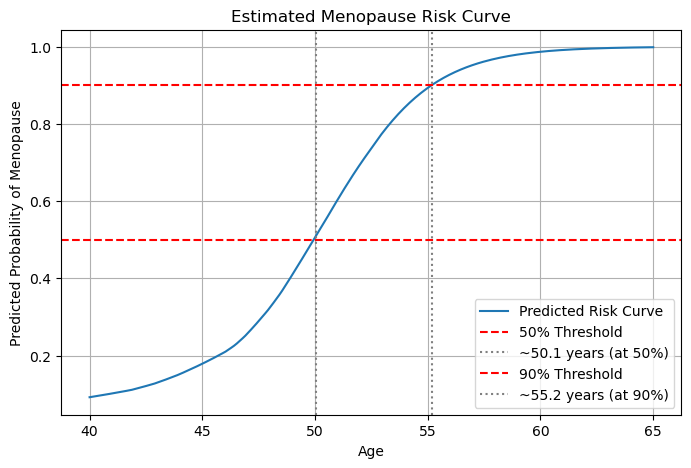

Estimated ages at thresholds:
At 50% probability: 50.1 years
At 90% probability: 55.2 years


In [17]:
patient_features = {
    'RHQ010': 13,     # Age at first period
    'RHQ420': 1,      # Birth control pills: 1 = yes
    'WHD120': 160,    # Weight at 25
    'WHD130': 65,     # Height at 25
    'SMQ020': 1       # Smoker: 1 = yes
}

estimated_ages = estimate_menopause_age_curve(
    model=best_models["MLP"],
    patient_features=patient_features,
    age_range=(40, 65),
    thresholds=[0.5, 0.9],
    plot=True
)

print("Estimated ages at thresholds:")
for t, a in estimated_ages.items():
    print(f"At {int(t*100)}% probability: {a:.1f} years")



✅ Interpretation for Clinicians
- Risk Curve: Shows how predicted menopause probability rises with age for this patient.
- Estimated Age: Age when risk crosses 50% (median menopause age prediction for this patient).
- Can also report 80% risk age, to show later certainty boundary.